# EcoBin: A Two Stage Waste Classification Model

The United States alone generated over [292.4 million tons of Municipal Solid Waste in 2018](https://www.epa.gov/facts-and-figures-about-materials-waste-and-recycling/national-overview-facts-and-figures-materials). Material Recovery Facilities (MRFs) are responsible for sorting and processing recyclable waste so that it can be reused by manufacturers, reducing the amount of waste sent to landfills and limiting the environmental damage that follows. However, a startling **[1 in 4 items in our recycling stream are contaminated](https://recyclops.com/understanding-recycling-contamination/)** and cannot be processed by MRFs. 

Recycling contamination stems from two sources:

1. **Wish-Cycling:** The practice of placing non-recyclable items like plastic bags and styrofoam into the recycling bin in the hope that they can be recycled. These items contaminate legitimate recyclables and drive up processing costs for MRFs. Fortunately, advances in *deep convolutional neural networks* have enabled classification models to categorize waste images with far greater accuracy than humans, reducing wish-cycling related problems. 

2. **Misclassification:** Although machines are able to classify waste with astonishingly high accuracy, a critical flaw remains. All existing waste classification models are trained to classify items based on their material composition. This approach fails to account for contamination. Consider the example of a pizza-stained cardboard box. A waste classification model may determine that the pizza-stained cardboard box is ***materially recyclable*** becuase it is made out of cardboard; however it fails to account for the ***contamination*** of the grease and food residue on the box that make it suited for the garbage bin instead.



This notebook takes a two-stage approach to solving the waste classification problem. It trains a **Stage A: Base Waste Classifier** to categorize items into either garbage, curbside recycling, drop-off recycling or hazard based on their material composition. It then trains a **Stage B: Contamination Classifier** to classify items as either a clean recyclable or a contaminated recyclable. Clean recyclables retain their Stage A classification, while contaminated recyclables are re-routed to garbage to reflect that they cannot be recycled in their current state.

## Step 0: Import Libraries

In [1]:
import os
import json
import random
import shutil
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import imagehash

from pathlib import Path
from PIL import Image
from collections import Counter

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

IMG_SIZE = 224
BATCH_SIZE = 32

2026-05-06 04:30:12.897069: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778041813.114371      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778041813.177224      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778041813.666098      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778041813.666140      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778041813.666144      57 computation_placer.cc:177] computation placer alr

## Step 1: Prepare Waste Classification Dataset

### 1.1 Download the Dataset

We will be using the [Recyclable and Household Waste Classification Dataset](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) by Alistair King to train the Stage A: Base Waste Classifier. This dataset contains 15,000 images (each 256x256 pixels) organized into 30 distinct classes of waste. We've chose this dataset becuase it covers a wide range of major waste categories like `Plastic`, `Paper and Cardboard`, `Glass`, `Metal`, `Organic Waste` and `Textiles`.  


It is important to note that each class in this dataset is further divided into 2 subcategories: `defualt` (studio-like images of waste items) and `real_world` (images of waste items in real-world environments). This allows us to train the model on how waste looks like in the real-world,

Finally, each class in the dataset contains 500 images and the images are evenly divided between the two subcategories for each class. 

In [2]:
# Download dataset from Kaggle
import kagglehub
path = kagglehub.dataset_download("alistairking/recyclable-and-household-waste-classification")
print(path)


# Initalize global variable DATASET_PATH and SPLITS_PATH
DATASET_PATH = Path("/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images")
SPLITS_PATH  = Path("/kaggle/working/splits")

/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification


### 1.2 Set the Random Seed

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1.3 Map Each Class of Waste to a Disposal Pathway

Each class of waste must be disposed differently. We will map each class of waste within the dataset to one of four disposal pathways: **garbage**, **curbside recycling**, **drop-off recycling** and **compost**. 

The United States has over 19,000 different municipalities and each municipality has different recycling rules and guidelines. Therefore, it's difficult to make a disposal mapping for each class of waste that's universally applicable to all municipalities in the nation. Consequently, we will be using the recycling guidelines for the City of Phoenix (the author's hometown) for this project.

In [4]:
# Lists all classes within dataset
os.listdir(DATASET_PATH)

['plastic_soda_bottles',
 'aerosol_cans',
 'steel_food_cans',
 'disposable_plastic_cutlery',
 'cardboard_boxes',
 'glass_beverage_bottles',
 'plastic_cup_lids',
 'plastic_straws',
 'plastic_shopping_bags',
 'styrofoam_cups',
 'cardboard_packaging',
 'glass_food_jars',
 'styrofoam_food_containers',
 'eggshells',
 'aluminum_food_cans',
 'coffee_grounds',
 'plastic_food_containers',
 'food_waste',
 'magazines',
 'shoes',
 'clothing',
 'aluminum_soda_cans',
 'plastic_detergent_bottles',
 'newspaper',
 'tea_bags',
 'office_paper',
 'plastic_water_bottles',
 'paper_cups',
 'glass_cosmetic_containers',
 'plastic_trash_bags']

In [5]:
# Initializes a dictionary mapping each class of waste within the dataset to a disposal pathway
DISPOSAL_MAP = {

    # Curbside Recycling: 17 classes
    'plastic_soda_bottles':       'curbside_recycling',
    'aerosol_cans':               'curbside_recycling',
    'steel_food_cans':            'curbside_recycling',
    'cardboard_boxes':            'curbside_recycling',
    'glass_beverage_bottles':     'curbside_recycling',
    'plastic_cup_lids':           'curbside_recycling',
    'cardboard_packaging':        'curbside_recycling',
    'glass_food_jars':            'curbside_recycling',
    'aluminum_food_cans':         'curbside_recycling',
    'plastic_food_containers':    'curbside_recycling',
    'magazines':                  'curbside_recycling',
    'aluminum_soda_cans':         'curbside_recycling',
    'plastic_detergent_bottles':  'curbside_recycling',
    'newspaper':                  'curbside_recycling',
    'office_paper':               'curbside_recycling',
    'plastic_water_bottles':      'curbside_recycling',
    'glass_cosmetic_containers':  'curbside_recycling',

    # Drop-off Recycling: 4 classes
    'plastic_shopping_bags':      'dropoff_recycling',
    'plastic_trash_bags':         'dropoff_recycling',
    'clothing':                   'dropoff_recycling',
    'shoes':                      'dropoff_recycling',

    # Compsot: 4 classes
    'eggshells':                  'compost',
    'coffee_grounds':             'compost',
    'tea_bags':                   'compost',
    'food_waste':                 'compost',

    # Garbage: 5 classes
    'disposable_plastic_cutlery': 'garbage',
    'styrofoam_cups':             'garbage',
    'styrofoam_food_containers':  'garbage',
    'plastic_straws':             'garbage',
    'paper_cups':                 'garbage',
}

### 1.4 Display Class Distribution

Now that we've mapped each class of waste to a disposal route, we can now audit the dataset. This cell looks up each class of waste's assigned disposal pathway from `DISPOSAL_MAP`, counts the number of images in that class and calculates the percent composition of each class out of the total size of the dataset. It then displays the metrics for each class in a table and writes a csv to the `/kaggle/working`. 

In [6]:
#---------------
# Table View
# --------------

# Appends each class of waste with disposal pathway and number of images into an empty array named records
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    count = sum(1 for f in class_dir.rglob('*') if f.is_file())
    pathway = DISPOSAL_MAP.get(class_name, 'UNMAPPED')
    records.append({'class': class_name, 'count': count, 'pathway': pathway}) # Appends image count and disposal route onto record

# Sorts values in the dataframe by count
df = pd.DataFrame(records).sort_values('count', ascending=False)

# Calculate percent composition of each class out of total dataset size
df['pct'] = (df['count'] / df['count'].sum() * 100).round(2)

# Print table to c and write csv to /kaggle/working
print(df[['class', 'count', 'pct', 'pathway']].to_string(index=False))
df[['class', 'count', 'pct', 'pathway']].to_csv('/kaggle/working/class_distribution_table.csv', index=False)
print("\nSaved to /kaggle/working/class_distribution_table.csv")

                     class  count  pct            pathway
              aerosol_cans    500 3.33 curbside_recycling
        aluminum_food_cans    500 3.33 curbside_recycling
        aluminum_soda_cans    500 3.33 curbside_recycling
           cardboard_boxes    500 3.33 curbside_recycling
       cardboard_packaging    500 3.33 curbside_recycling
                  clothing    500 3.33  dropoff_recycling
            coffee_grounds    500 3.33            compost
disposable_plastic_cutlery    500 3.33            garbage
                 eggshells    500 3.33            compost
                food_waste    500 3.33            compost
    glass_beverage_bottles    500 3.33 curbside_recycling
 glass_cosmetic_containers    500 3.33 curbside_recycling
           glass_food_jars    500 3.33 curbside_recycling
                 magazines    500 3.33 curbside_recycling
                 newspaper    500 3.33 curbside_recycling
              office_paper    500 3.33 curbside_recycling
              

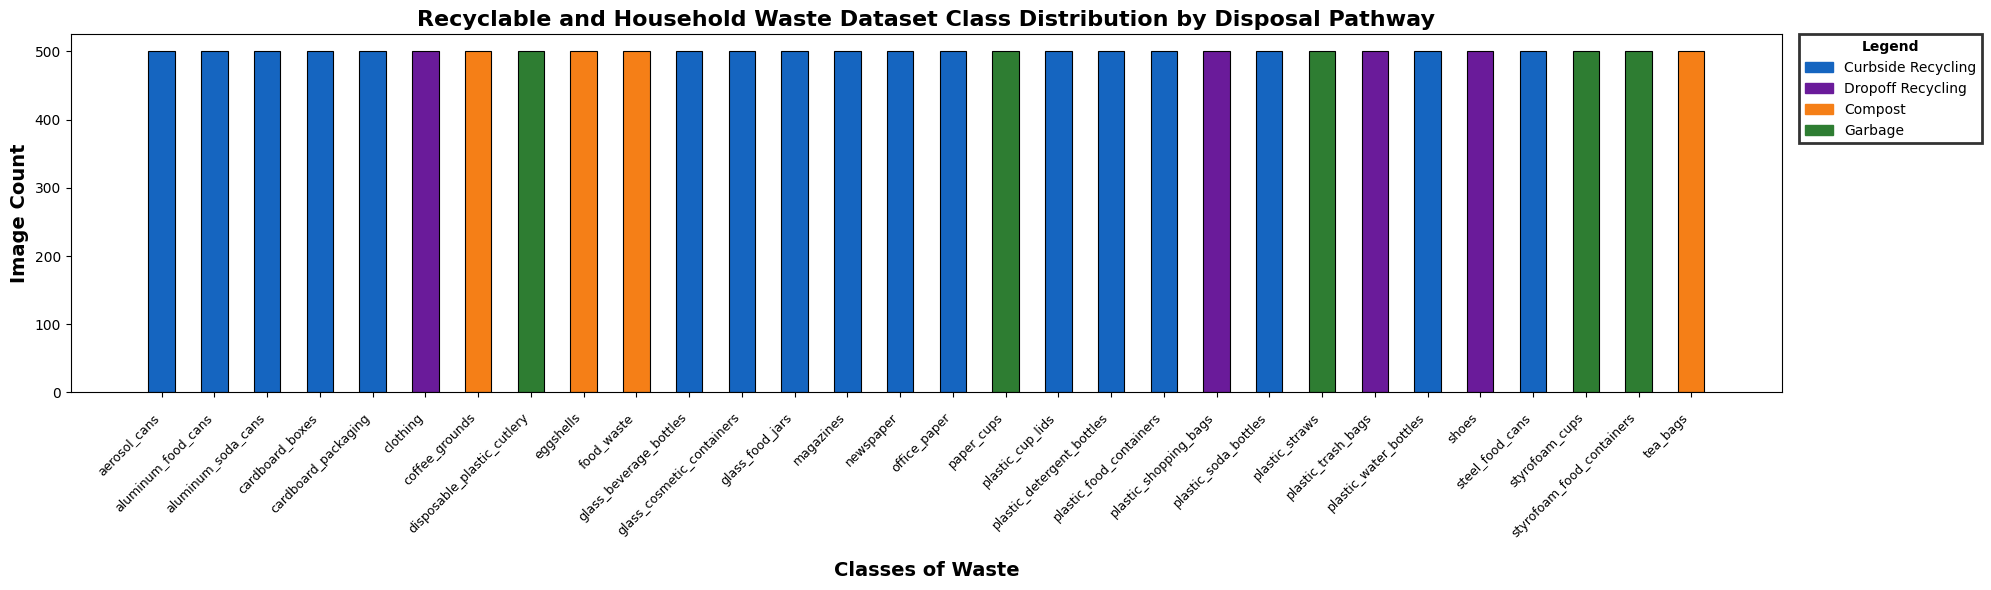

In [7]:
#---------------
# Bar Chart View
# --------------

# Initalize dictionary mapping disposal pathways to color for the legend
PATHWAY_COLORS = {
    'curbside_recycling': '#1565C0',
    'dropoff_recycling':  '#6A1B9A',
    'compost':            '#F57F17',
    'garbage':            '#2E7D32',
    'UNMAPPED':           '#B71C1C',
}

# Display class distribution in bar chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(df['class'], df['count'], width=0.5,
       color=[PATHWAY_COLORS.get(p, '#B71C1C') for p in df['pathway']],
       edgecolor='black', linewidth=0.8)

ax.set_xticks(range(len(df['class'])))
ax.set_xticklabels(df['class'], rotation=45, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=10)

ax.set_xlabel('Classes of Waste', fontweight='bold', fontsize=14, labelpad=15)
ax.set_ylabel('Image Count', fontweight='bold', fontsize=14)
ax.set_title('Recyclable and Household Waste Dataset Class Distribution by Disposal Pathway', fontweight='bold', fontsize=16)

legend = ax.legend(
    handles=[mpatches.Patch(color=c, label=p.replace('_', ' ').title())
             for p, c in PATHWAY_COLORS.items() if p in df['pathway'].values],
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    title='Legend',
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=True,
    edgecolor='black',
    fancybox=False,
)
legend.get_frame().set_linewidth(2)

# Plot bar chart and save image to /kaggle/working
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In this case we can see in both the table and the bar chart that all classes in the dataset have the same sample size (e.g. 500 images), so we don't have to worry about assigning class weights. 

### 1.5 Split Dataset into Train/Val/Test

To train the model we will split the dataset into three paths: **train (70%)**, **validation (15%)** and **test (15%)**. During the split, test images are additionally written into two subcategory-specific directories, `test_default` and `test_real_world`, based on the `default` or `real_world` subfolder each image comes from. These directories help us evaluate the model on separate test sets in step 2.8

In [8]:
SPLITS_PATH = Path('data')

# Clear old splits if they exist
if SPLITS_PATH.exists():
    shutil.rmtree(SPLITS_PATH)
    print("Cleared old splits")

# Loop through all images in each class and assign to train, val, or test
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name

    images = [f for f in class_dir.rglob('*') if f.is_file()]
    if len(images) < 10:
        print(f"WARNING: {class_name} only has {len(images)} images - skipping")
        continue

    train_imgs, temp    = train_test_split(images, test_size=0.30, random_state=SEED)
    val_imgs, test_imgs = train_test_split(temp,   test_size=0.50, random_state=SEED)

    for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        split_dir = SPLITS_PATH / split / class_name
        split_dir.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            # Prefix with parent subfolder name to avoid filename collisions
            unique_name = f"{img.parent.name}_{img.name}"
            shutil.copy2(img, split_dir / unique_name)

            # Copy test images into subcategory directories for Section 2.8 evaluation
            if split == 'test':
                subcat_dir = SPLITS_PATH / f'test_{img.parent.name}' / class_name
                subcat_dir.mkdir(parents=True, exist_ok=True)
                shutil.copy2(img, subcat_dir / unique_name)

# Print Splits
print("Train/val/test split complete")
print(f"  Train:           {sum(1 for _ in (SPLITS_PATH/'train').rglob('*')        if _.is_file())} images")
print(f"  Val:             {sum(1 for _ in (SPLITS_PATH/'val').rglob('*')          if _.is_file())} images")
print(f"  Test:            {sum(1 for _ in (SPLITS_PATH/'test').rglob('*')         if _.is_file())} images")
print(f"  Test Default:    {sum(1 for _ in (SPLITS_PATH/'test_default').rglob('*') if _.is_file())} images")
print(f"  Test Real World: {sum(1 for _ in (SPLITS_PATH/'test_real_world').rglob('*') if _.is_file())} images")

Train/val/test split complete
  Train:           10500 images
  Val:             2250 images
  Test:            2250 images
  Test Default:    1140 images
  Test Real World: 1110 images


## Step 2: Train the Stage A: Base Waste Classifier

### 2.1 Load Split Dataset

We begin by loading the train, validation, and test splits from the disk onto the TensorFlow datasets. All images are then resized to 224×224 pixels and grouped into batches of 32. Two additional datasets, `test_default_ds` and `test_real_world_ds`, are loaded from the subcategory directories created in Step 1.5.

The data pipeline is optimized for GPU training using three operations:

- **cache:** stores images in memory after the first epoch so they are not re-read from disk each epoch
- **shuffle:** randomly reorders the training set each epoch so the model does not see classes in the same order
- **prefetch:** loads the next batch on the CPU while the GPU trains on the current one, eliminating idle time between batches

**Note:** Shuffling is applied to the training set only to prevent the model from learning patterns in the order of the data. The order the images appear in the validation and test sets has no effect on the final metrics, so images are not shuffled in those sets.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

'''
Load split datasets from disk into TensorFlow datasets
Images are resized to 224x224 pixels and grouped into batches of 32
label_mode='categorical' returns one-hot labels required by CategoricalCrossentropy
'''

# Training Dataset - train
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Validatio Dataset - val
val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset - test
test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Default Images - test_default
test_default_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_default'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

# Test Dataset of Real World Images - test_real_world
test_real_world_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLITS_PATH / 'test_real_world'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names) # Sets number of neurons in Dense layer to 30
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {class_names}")

# Images are stored in memory after first epoch so they don't get re-read every time
train_ds           = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) # Images shuffled in train set
val_ds             = val_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Loads next batch on CPU
test_ds            = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_default_ds    = test_default_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_real_world_ds = test_real_world_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 10500 files belonging to 30 classes.


I0000 00:00:1778041956.029757      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2250 files belonging to 30 classes.
Found 2250 files belonging to 30 classes.
Found 1140 files belonging to 30 classes.
Found 1110 files belonging to 30 classes.
Number of classes: 30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']


### 2.2 Apply Data Augmentation Techniques

We apply data augmentation techniques to the train set to prevent the model from overfitting. ***Model Overfitting*** occurs when the model learns the training data too well capturing and doesn't learn the underlying patterns. This usually results in high accuracy on training data but low accuracy on validation and test splits. To prevent overfitting for our Stage A: Base Waste Classifier we manipulate and distort the images using data augmentation to ensure the model learns underlying patterns of the training data.

| Technique | Parameter | Purpose |
|---|---|---|
| RandomRotation | ±60° | Randomly rotates training images by 60 degrees left or right |
| RandomZoom | ±20% | Randomly zooms in or out on the training image by 20% |
| RandomTranslation | ±15% | Randomly translates training images 15% left or right |
| RandomFlip | Horizontal and vertical | Randomly flips the training image horizontally or vertically |
| RandomBrightness | ±30% | Randomly increases or decreases lighting on training image by 20% |
| RandomContrast | ±30% | Randomly increases or decreases contrast on training image by 20% |

**Note:** Augmentation is applied during training becuase we're preventing the model from overfitting to the data in that phase. The validation and test sets will only use unaugmented images

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=60/360),
    layers.RandomZoom(height_factor=0.2),
    layers.RandomTranslation(height_factor=0.15, width_factor=0.15),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomBrightness(factor=0.3),
    layers.RandomContrast(factor=0.3),
], name="augmentation")

### 2.3 Build the Stage A Base Waste Classifier

For the Stage A Base Waste Classifier we will be using a MobileNetV3Large model as a frozen feature extractor with a custom classification head. We use transfer learning from ImageNet weights, so we don't have to train the model on low-level feature detection from scratch. Instead we focus on only training the classification head (the last layer) across the 30 classes of waste. 

| Layer | Output Shape | Params | Purpose |
|---|---|---|---|
| InputLayer | (None, 224, 224, 3) | 0 | Defines the expected image dimensions to be 224×224 pixels across 3 RGB channels |
| Data Augmentation | (None, 224, 224, 3) | 0 | Applies random transformations from Step 2.2 during training only |
| MobileNetV3Large | (None, 7, 7, 960) | 2,996,352 | Pretrained feature extractor with ImageNet weights compresses each image into a 7×7 grid of 960 features |
| GlobalAveragePooling2D | (None, 960) | 0 | Collapses the 7×7×960 feature map into a flat 960-value vector by averaging each channel |
| BatchNormalization | (None, 960) | 3,840 | Normalizes the pooled feature vector to stabilize training and improve gradient flow |
| Dropout | (None, 960) | 0 | Randomly zeros 40% of features during training |
| Dense (256, ReLU + L2) | (None, 256) | 246,016 | Learns a compressed 256-dimensional representation with L2 regularization (1e-4) to penalize large weights and improve generalization |
| Dense (30, Softmax) | (None, 30) | 7,710 | Outputs a probability distribution across all 30 waste classes |

In [11]:
def build_stage_a(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    base_model = MobileNetV3Large(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,           # Removes ImageNet Classification Head
        weights='imagenet',           # Loads ImageNet weights
        include_preprocessing=True    # Handles pixel normalization to 0-1 scale
    )
    base_model.trainable = False      # Freezes backbone parameters so only classification head is trained
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)  # Collapses output to flat vector of 960 values by averaging color channels
    x = layers.BatchNormalization()(x)       # Normalizes pooled features to stabilize fine-tuning
    x = layers.Dropout(0.4)(x)              # Randomly turns off 40% of neurons to reduce overfitting
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)  # Compressed 256D representation with L2 regularization
    outputs = layers.Dense(num_classes, activation='softmax')(x)             # Produces probability distribution across all 30 waste classes
    model = Model(inputs, outputs, name="stage_a")
    return model, base_model

model_a, base_model = build_stage_a(NUM_CLASSES)
model_a.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "stage_a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,253,918 (12.41 MB)

 Trainable params: 255,646 (998.62 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

### 2.4 Define Traing Callbacks

Callbacks are objects that monitor training and automatically take actions at the end of each epoch. In this cell we define three callbacks and pass them into every `model.fit()` call in Step 2.5.

| Callback | Monitors | Action |
|---|---|---|
| ModelCheckpoint | val_accuracy | Saves model weights to disk whenever val_accuracy improves |
| EarlyStopping | val_accuracy | Stops training if val_accuracy does not improve for 7 consecutive epochs |
| ReduceLROnPlateau | val_loss | Halves the learning rate if val_loss does not improve for 3 consecutive epochs, down to a floor of 1e-6 |

In [12]:
# Checks whether val_accuracy improved after every epoch
checkpoint_cb = ModelCheckpoint(
    'stage_a_best.keras',
    monitor='val_accuracy',
    save_best_only=True, # Overwrites stage_a_best.keras with best model weights
    verbose=1
)

# Stops training if val_accuracy does not improve for 7 consecutive epochs
early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True # Rolls model back to epoch with best weights
)

# Halves learning rate when val_loss does not improve for 3 consecutive epochs, down to 1e-6
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

### 2.5.2 Model Training 1 (Phase 1 and 2)

This cell trains the Stage A: Base Waste Classifier across two progressive phases.

1. **Phase 1 (30 epochs, lr=1e-3):** We freeze the entire MobileNetV3Large backbone and only train the classification head (the last layer). We also activate ReduceLROnPlateau is to reduce the learning rate when val loss stalls and EarlyStopping to cut the phase short if the head fully converges before 30 epochs.

2. **Phase 2 (30 epochs, lr=5e-5):** We keep layers 0-100 remain frozen. However, we unfreeze layers 101 onward (`expanded_conv_9` through `conv_1`), exposing six convolutional blocks to gradient updates. This gives the model more capacity to adapt its feature extraction to waste images than just what unfreezing the classification head can do. The learning rate is held at 5e-5 (one-fifth of the Phase 1 value) and gradient clipping (`clipnorm=1.0`) caps the magnitude of any single update to prevent disrupting the pre-trained backbone weights. Both EarlyStopping and ReduceLROnPlateau remain active.

In [13]:
# Phase 1: Freeze backbone and train classification head only
print("=== Phase 1 ===")
base_model.trainable = False
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_p1 = model_a.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb], # All callbacks are activated
    verbose=1
)

# Phase 2: Unfreeze backbone from expanded_conv_9 onwards
print("\n=== Phase 2 ===")
base_model.trainable = True
for layer in base_model.layers[:101]:
    layer.trainable = False
for layer in base_model.layers[101:]:
    layer.trainable = True
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_p2 = model_a.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb], # All callbacks are activated
    verbose=1
)

=== Phase 1 ===
Epoch 1/30


I0000 00:00:1778041981.421788     254 cuda_dnn.cc:529] Loaded cuDNN version 91002


329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3734 - loss: 2.6657
Epoch 1: val_accuracy improved from -inf to 0.72578, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.3737 - loss: 2.6646 - val_accuracy: 0.7258 - val_loss: 1.5472 - learning_rate: 0.0010
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5868 - loss: 1.9056
Epoch 2: val_accuracy improved from 0.72578 to 0.73644, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.5868 - loss: 1.9055 - val_accuracy: 0.7364 - val_loss: 1.5044 - learning_rate: 0.0010
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6315 - loss: 1.7615
Epoch 3: val_accuracy improved from 0.73644 to 0.74311, saving model to stage_a_best.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.6315 - loss: 1.7614 - val_accuracy: 0.7431 - val_loss: 1.4561 - learning_rate: 0.0010
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/ste

In [14]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, "| trainable:", layer.trainable)

0 input_layer_2 | trainable: False
1 rescaling | trainable: False
2 conv | trainable: False
3 conv_bn | trainable: False
4 activation | trainable: False
5 expanded_conv_depthwise | trainable: False
6 expanded_conv_depthwise_bn | trainable: False
7 re_lu | trainable: False
8 expanded_conv_project | trainable: False
9 expanded_conv_project_bn | trainable: False
10 expanded_conv_add | trainable: False
11 expanded_conv_1_expand | trainable: False
12 expanded_conv_1_expand_bn | trainable: False
13 re_lu_1 | trainable: False
14 expanded_conv_1_depthwise_pad | trainable: False
15 expanded_conv_1_depthwise | trainable: False
16 expanded_conv_1_depthwise_bn | trainable: False
17 re_lu_2 | trainable: False
18 expanded_conv_1_project | trainable: False
19 expanded_conv_1_project_bn | trainable: False
20 expanded_conv_2_expand | trainable: False
21 expanded_conv_2_expand_bn | trainable: False
22 re_lu_3 | trainable: False
23 expanded_conv_2_depthwise | trainable: False
24 expanded_conv_2_depthwise

In [21]:
import os
os.makedirs('/kaggle/working/stage_a_results', exist_ok=True)
print("Created /kaggle/working/stage_a_results")

Created /kaggle/working/stage_a_results


### 2.6 Plot Stage A Training vs Validation Error Metrics

Before we evaluate the Stage A: Base Waste Classifier on the held-out test set, we have to examine its training/validation accuracy and loss curves across both training phases. 

**Phase 1 (epochs 1 - 27):** Looking at the graph we can see that training accuracy rises from roughly 50% to 80% while validation accuracy closely tracks it, reaching around 82%. Training and validation loss both fall steeply and remain close together throughout this phase. Moreover, he tight gap between the two curves indicates the model is generalizing well rather than memorizing the training data at this stage. That's good as it signal there isn't any overfitting.

**Phase 2 (epochs 28 - 55):** After unfreezing the top convolutional blockwe can see an immediatespike in training loss and dip in training accuracy. However, this spike is brief and it is expected behavior when a new set of weights is exposed to a lower learning rate optimizer for the first time. For the rest of the phase, raining accuracy continues climbing to roughly 95% by the final epoch, while validation accuracy stabilizes around 86%.

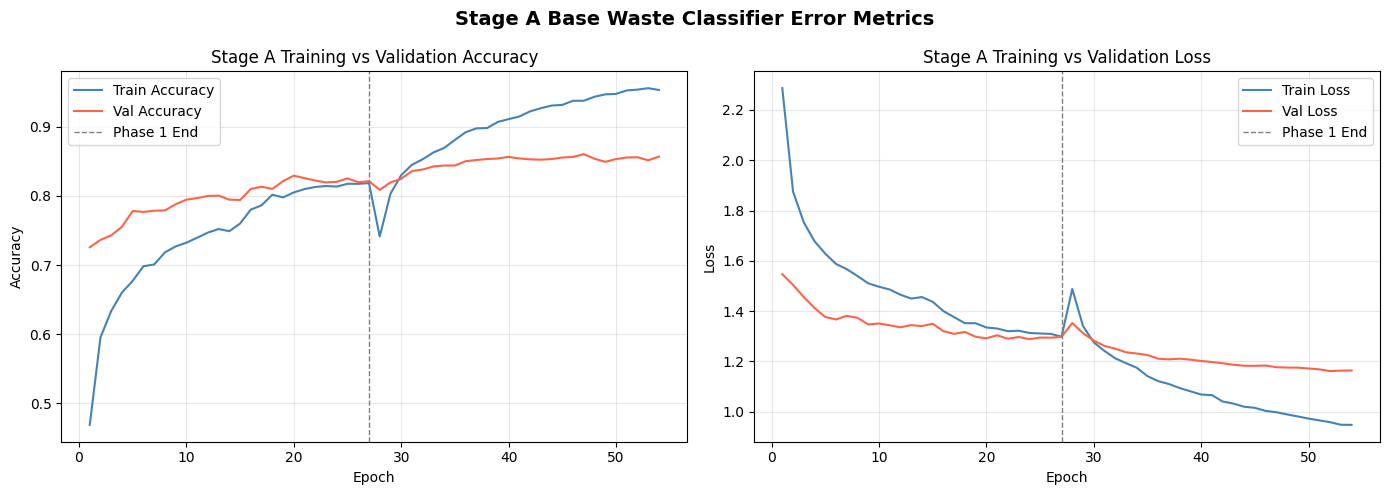

In [23]:
# Combine history across both phases
def combine_histories(histories):
    combined = {}
    for key in histories[0].history.keys():
        combined[key] = []
        for hist in histories:
            combined[key].extend(hist.history[key])
    return combined

history_combined = combine_histories([history_p1, history_p2])
epochs = range(1, len(history_combined['accuracy']) + 1)

# Mark the end of Phase 1 on the plot
p1_end = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Stage A Accuracy
ax1.plot(epochs, history_combined['accuracy'],     label='Train Accuracy', color='steelblue')
ax1.plot(epochs, history_combined['val_accuracy'], label='Val Accuracy',   color='tomato')
ax1.axvline(x=p1_end, color='gray', linestyle='--', linewidth=1, label='Phase 1 End')
ax1.set_title('Stage A Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Stage A Loss
ax2.plot(epochs, history_combined['loss'],     label='Train Loss', color='steelblue')
ax2.plot(epochs, history_combined['val_loss'], label='Val Loss',   color='tomato')
ax2.axvline(x=p1_end, color='gray', linestyle='--', linewidth=1, label='Phase 1 End')
ax2.set_title('Stage A Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Stage A Base Waste Classifier Error Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/stage_a_results/stage_a_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Evaluate Stage A Base Waste Classifier on Test Set

Now we can evaluate the Stage A: Base Waste Classifier on the held out test. The test set has a total of 2,250 images, meaning each class will 75 test images. We will be analyzing 4 metrics when evaluating the results of the test set. 

1. **Accuracy:** The proportion of all predictions that are correct. 
2. **Precision:**  The measure of how often the model is correct when it predicts a given class. 
3. **Recall:** The measure of how often the model correctly identifies all true members of a class. 
4. **F1:** The the harmonic mean of precision and recall.

Together, these four metrics give a more complete picture of model behavior than any single number alone. A model could achieve high accuracy by performing well on easy, common classes while failing on harder ones. Examining all four metrics per class reveals exactly where the model is reliable and where it is not.

In [24]:
# ---------------
# Table View
# ---------------

from sklearn.metrics import precision_score, recall_score, f1_score

best_model_a = tf.keras.models.load_model('stage_a_best.keras')

# Run predictions on full test set
all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = best_model_a.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer class indices

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute per-class accuracy and sort descending
cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
sorted_indices     = np.argsort(per_class_accuracy)[::-1]

report = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Print classification report organized by accuracy per class in descending order
print("Stage A Classification Report")
print("=" * 75)
print(f"{'Class':<35} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 75)
for i in sorted_indices:
    name = class_names[i]
    acc  = per_class_accuracy[i]
    p    = report[name]['precision']
    r    = report[name]['recall']
    f1   = report[name]['f1-score']
    sup  = int(report[name]['support'])
    print(f"{name:<35} {acc:>9.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {sup:>9}")
print("-" * 75)
print(f"{'macro avg':<35} {np.mean(per_class_accuracy):>9.4f} {report['macro avg']['precision']:>10.4f} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>8.4f} {int(report['macro avg']['support']):>9}")

Stage A Classification Report
Class                                Accuracy  Precision   Recall       F1   Support
---------------------------------------------------------------------------
coffee_grounds                         0.9867     0.9250   0.9867   0.9548        75
food_waste                             0.9600     0.9863   0.9600   0.9730        75
styrofoam_food_containers              0.9467     0.8161   0.9467   0.8765        75
shoes                                  0.9467     0.8987   0.9467   0.9221        75
eggshells                              0.9333     0.9722   0.9333   0.9524        75
glass_food_jars                        0.9200     0.8313   0.9200   0.8734        75
magazines                              0.9200     0.8118   0.9200   0.8625        75
plastic_straws                         0.9067     0.8947   0.9067   0.9007        75
disposable_plastic_cutlery             0.9067     0.9714   0.9067   0.9379        75
aerosol_cans                           0.906

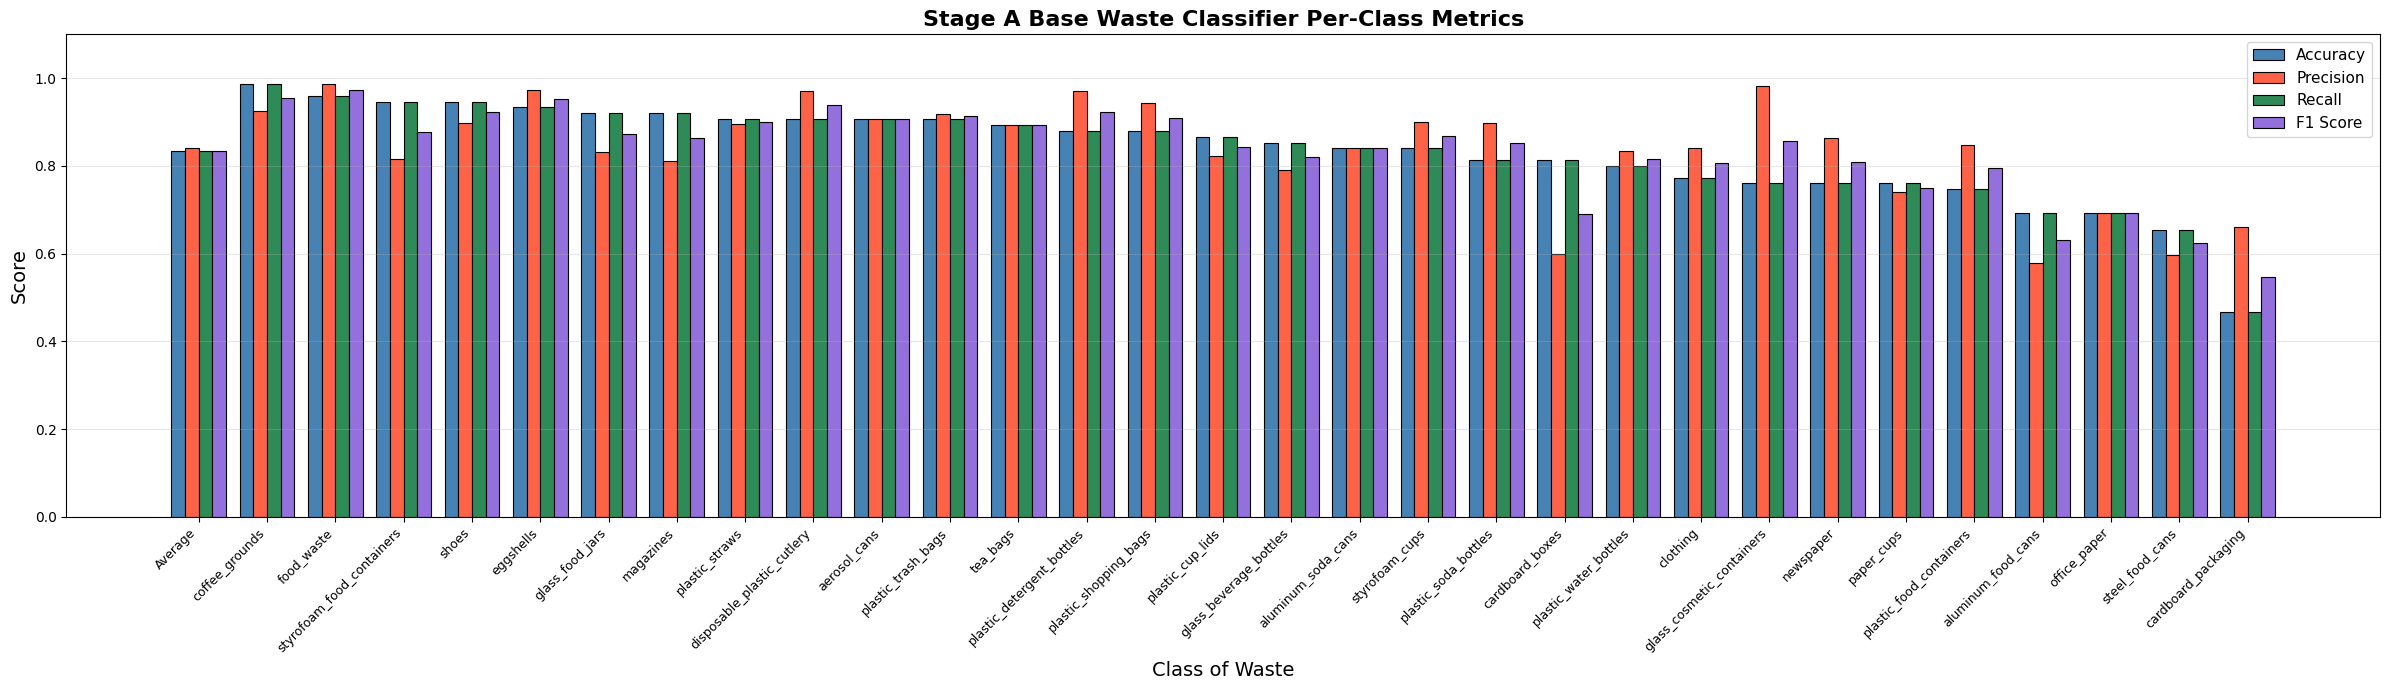


Overall Metrics
Accuracy:  0.8342
Precision: 0.8409
Recall:    0.8342
F1 Score:  0.8347


In [27]:
# ---------------
# Bar Chart View
# ---------------

# Calculates Per-Class Metrics
per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

# Calculates average accuracy, precision, recall and F1
avg_accuracy  = np.mean(per_class_accuracy)
avg_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
avg_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
avg_f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)

# Sort classes by descending accuracy, average bar first
sorted_labels    = ['Average'] + [class_names[i] for i in sorted_indices]
sorted_accuracy  = [avg_accuracy]  + [per_class_accuracy[i]  for i in sorted_indices]
sorted_precision = [avg_precision] + [per_class_precision[i] for i in sorted_indices]
sorted_recall    = [avg_recall]    + [per_class_recall[i]    for i in sorted_indices]
sorted_f1        = [avg_f1]        + [per_class_f1[i]        for i in sorted_indices]

x     = np.arange(len(sorted_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(24, 7))
ax.bar(x - 1.5*width, sorted_accuracy,  width, label='Accuracy',  color='steelblue',   edgecolor='black', linewidth=0.8)
ax.bar(x - 0.5*width, sorted_precision, width, label='Precision', color='tomato',       edgecolor='black', linewidth=0.8)
ax.bar(x + 0.5*width, sorted_recall,    width, label='Recall',    color='seagreen',     edgecolor='black', linewidth=0.8)
ax.bar(x + 1.5*width, sorted_f1,        width, label='F1 Score',  color='mediumpurple', edgecolor='black', linewidth=0.8)

ax.set_title('Stage A Base Waste Classifier Per-Class Metrics', fontsize=16, fontweight='bold')
ax.set_xlabel('Class of Waste', fontsize=14,)
ax.set_ylabel('Score', fontsize=14,)
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/stage_a_results/stage_a_per_class_metrics_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall Metrics")
print(f"{'='*40}")
print(f"Accuracy:  {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall:    {avg_recall:.4f}")
print(f"F1 Score:  {avg_f1:.4f}")

After reading the table and visualizing the results on the bar chart, we can make a couple of conlusions.

**Overall Performance:** Stage A achieves a macro-average accuracy of 83.4%, with precision, recall, and F1 all clustering tightly around the same value. The consistency across these three metrics suggests the model is neither systematically over-predicting nor under-predicting any particular disposal pathway at the aggregate level, which is good as it tells us our training strategy was effective and reliable. 

However, the accuracy of ~83% is low compared to state-of-the-art waste classification models which often boast accuracy rates of 95% or greater. However, we can excuse this as we are training the model across 30 different outputs and our goal is accuracy in disposal routing (garbage, curbside recycling, drop-off recycling and compost), not what the object actually is.

**Strong performers:** The top of the table is dominated by visually distinctive classes. Coffee grounds (98.7%), food waste (96.0%), and styrofoam food containers (94.7%) all exceed 94% accuracy. These classes tend to have consistent textures and colors that make them relatively easy to discriminate even across the different image sources in the dataset.

**Weak performers:** The bottom of the table reveals a clear pattern. The three lowest-accuracy classes are cardboard packaging (46.7%), steel food cans (65.3%), and cardboard boxes (81.3%). The cardboard confusion is unsurprising: cardboard boxes and cardboard packaging are visually nearly identical and share the same material, differing only in form factor. The model struggles to learn a reliable boundary between them. Similarly, aluminum food cans and steel food cans are easily confused due to their similar cylindrical shape and metallic appearance, which likely explains the lower performance on both.

**Precision-recall asymmetry:** Several classes show a notable gap between precision and recall. Glass cosmetic containers, for example, has very high precision (98.3%) but relatively low recall (76.0%), meaning the model is conservative about predicting this class and tends to miss true instances rather than over-predict them. Cardboard boxes shows the opposite pattern, with low precision (59.8%) and higher recall (81.3%), indicating the model over-predicts this class and pulls in items that belong to neighboring categories like cardboard packaging.

### 2.8 Default vs Real World Test Set Evaluation

Up to this point, Stage A has been evaluated on a held-out test set drawn from the full dataset, which mixes both the `default` and `real_world` images together. That overall accuracy number is useful, but it obscures an important question: does Stage A perform equally well on studio images and real-world images, or does performance degrade when the background is cluttered and lighting is inconsistent?

In this cell we'll compare the results of the Stage A: Base Waste Classifier on both the `default` and `real_world` test sets. The difference between in accuracy is the domain gap. Generally, we expect the model to have higher accuracy on the `default` images. 

Default    Overall Accuracy: 0.8614
Real World Overall Accuracy: 0.8063
Domain Gap:                 +0.0551

Class                                 Default  Real World      Gap
------------------------------------------------------------------
cardboard_packaging                    0.4211      0.5135  -0.0925
office_paper                           0.7895      0.5946  +0.1949
newspaper                              0.8947      0.6216  +0.2731
aluminum_food_cans                     0.7632      0.6216  +0.1415
plastic_food_containers                0.8158      0.6757  +0.1401
paper_cups                             0.8158      0.7027  +0.1131
steel_food_cans                        0.6053      0.7027  -0.0974
clothing                               0.8158      0.7297  +0.0861
styrofoam_cups                         0.9211      0.7568  +0.1643
glass_beverage_bottles                 0.9474      0.7568  +0.1906
plastic_water_bottles                  0.8158      0.7838  +0.0320
plastic_shopping_bag

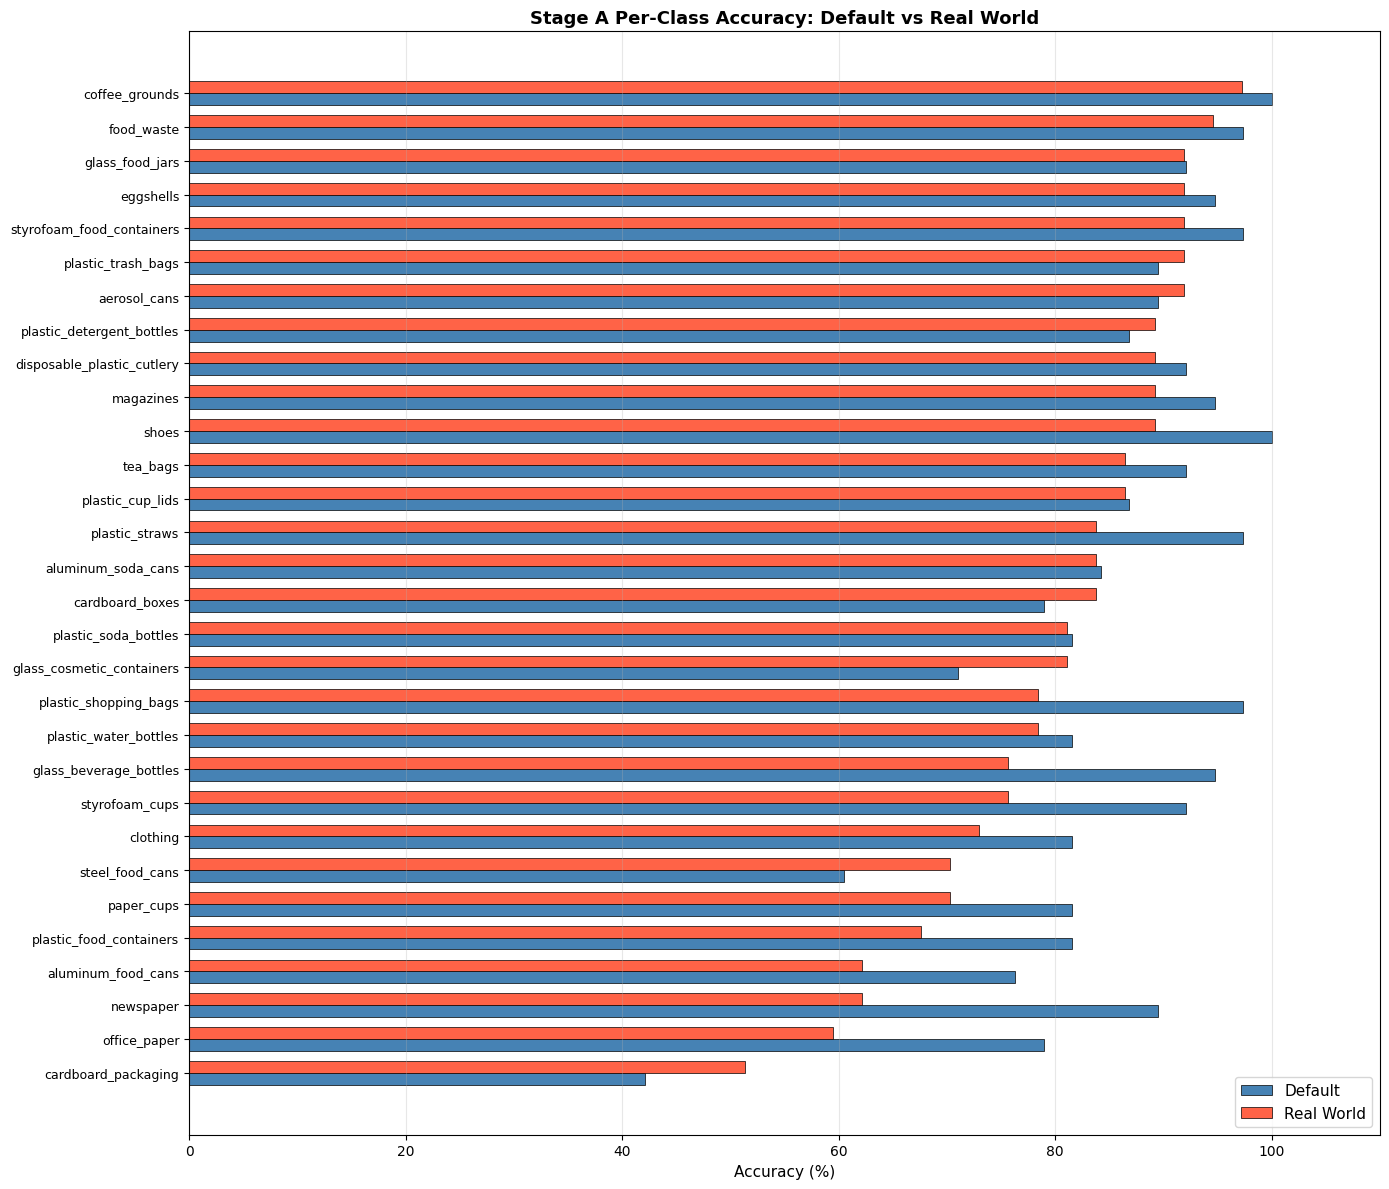

In [18]:
def evaluate_subcategory(model, dataset):
    preds, labels = [], []
    for images, label_batch in dataset:
        batch_preds = model.predict(images, verbose=0)
        preds.extend(np.argmax(batch_preds, axis=1))
        labels.extend(np.argmax(label_batch.numpy(), axis=1))  # Convert one-hot to integer class indices
    return np.array(preds), np.array(labels)

preds_default, labels_default = evaluate_subcategory(best_model_a, test_default_ds)
preds_real,    labels_real    = evaluate_subcategory(best_model_a, test_real_world_ds)

# Compute per-class accuracy for each subcategory
def per_class_acc(labels, preds):
    cm_sub  = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    row_sum = cm_sub.sum(axis=1)
    row_sum[row_sum == 0] = 1  # Avoid division by zero for any empty class
    return cm_sub.diagonal() / row_sum

acc_default = per_class_acc(labels_default, preds_default)
acc_real    = per_class_acc(labels_real,    preds_real)

# Print overall accuracy for each subcategory
print(f"Default    Overall Accuracy: {acc_default.mean():.4f}")
print(f"Real World Overall Accuracy: {acc_real.mean():.4f}")
print(f"Domain Gap:                 {acc_default.mean() - acc_real.mean():+.4f}")

# Print per-class comparison table sorted by real_world accuracy ascending
sorted_by_real = np.argsort(acc_real)
print(f"\n{'Class':<35} {'Default':>9} {'Real World':>11} {'Gap':>8}")
print("-" * 66)
for i in sorted_by_real:
    gap = acc_default[i] - acc_real[i]
    print(f"{class_names[i]:<35} {acc_default[i]:>9.4f} {acc_real[i]:>11.4f} {gap:>+8.4f}")

# Sort ascending so highest real_world accuracy is at the top of the chart
sort_idx       = np.argsort(acc_real)
sorted_names   = [class_names[i] for i in sort_idx]
sorted_default = [acc_default[i] * 100 for i in sort_idx]
sorted_real    = [acc_real[i]    * 100 for i in sort_idx]

y      = np.arange(len(sorted_names))
height = 0.35

fig, ax = plt.subplots(figsize=(14, 12))
ax.barh(y - height/2, sorted_default, height, label='Default',    color='steelblue', edgecolor='black', linewidth=0.5)
ax.barh(y + height/2, sorted_real,    height, label='Real World', color='tomato',    edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Stage A Per-Class Accuracy: Default vs Real World', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/stage_a_results/stage_a_default_vs_real_world_results.png', dpi=150, bbox_inches='tight')
plt.show()

Stage A achieves a **default subcategory accuracy of 86.1%** and a **real-world subcategory accuracy of 80.6%**, producing an overall domain gap of 5.5 percentage points. This is a relatively modest gap, suggesting the model has learned features that generalize reasonably well beyond studio conditions.

### 2.9 Confusion Matrices

We'll plot two confusion matrices for the Stage A: Base Waste Classifer. The first is a **class-level confusion matrix across all 30 waste categories**. Confusion matrices provide a detailed breakdown of model performance by comparing each predicted class against the actual ground truth label. A well-performing model will show a dark diagonal from top-left to bottom-right, indicating that most items are being classified correctly.

The second is a **disposal pathway confusion matrix collapsed across the 4 disposal pathways**. This is the more meaningful evaluation for EcoBin's real-world purpose. What ultimately matters is not whether the model identifies the exact object, but whether it routes that object to the correct bin. Evaluating at the pathway level also naturally absorbs errors between visually similar classes that share the same route, such as `cardboard_boxes` and `cardboard_packaging`, which both map to curbside recycling. A class-level error between these two is inconsequential in practice and should not count against the model.

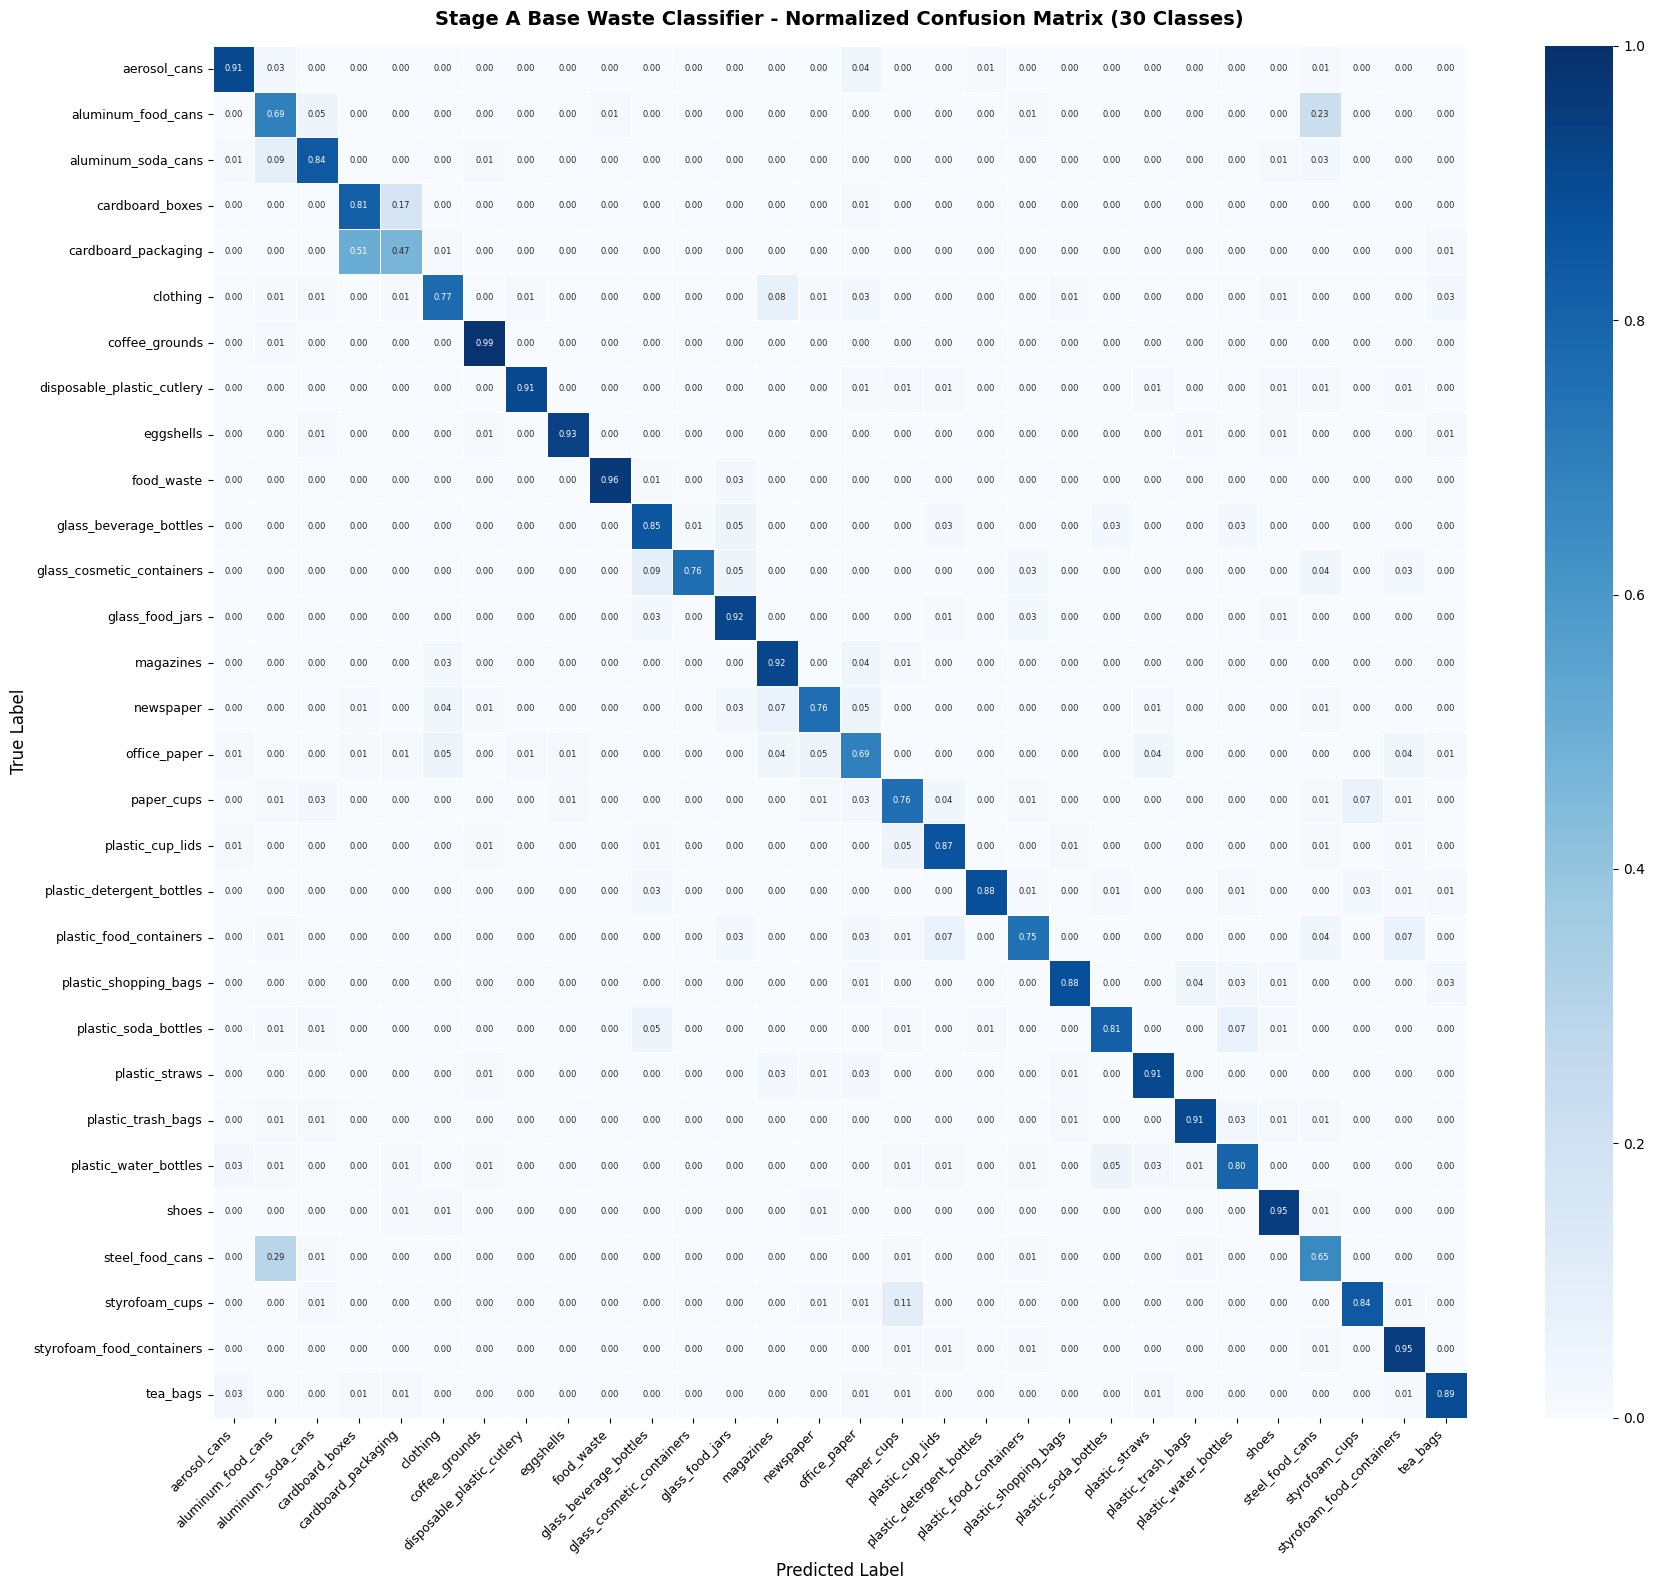

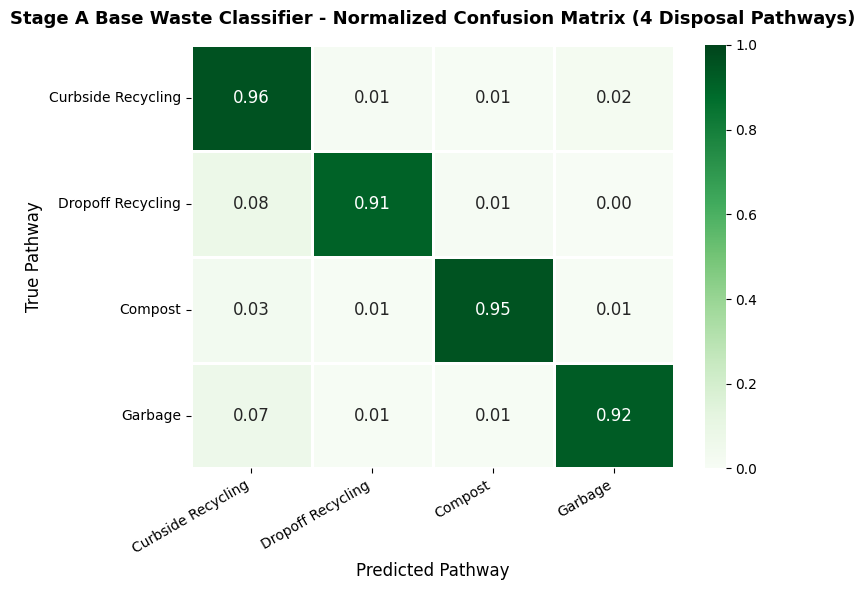

In [19]:
# ----------------------------
# Class-level Confusion Matrix
# ----------------------------

# Normalize class confusion matrix so each row sums to 1
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 6},
    vmin=0,
    vmax=1
)

# Print Class-level Confuson Matrix
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (30 Classes)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('stage_a_confusion_matrix_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------
# Disposal Pathway Confusion Matrix
# ---------------------------------

# Build disposal pathway confusion matrix
PATHWAY_ORDER  = ['curbside_recycling', 'dropoff_recycling', 'compost', 'garbage']
PATHWAY_LABELS = [p.replace('_', ' ').title() for p in PATHWAY_ORDER]

pathway_true = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_labels]
pathway_pred = [DISPOSAL_MAP.get(class_names[i], 'UNMAPPED') for i in all_preds]

cm_pathway      = confusion_matrix(pathway_true, pathway_pred, labels=PATHWAY_ORDER)
cm_pathway_norm = cm_pathway.astype(float) / cm_pathway.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_pathway_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=PATHWAY_LABELS,
    yticklabels=PATHWAY_LABELS,
    ax=ax,
    linewidths=1,
    annot_kws={'size': 12},
    vmin=0,
    vmax=1
)

# Print Disposal Pathway Confusion Matrix
ax.set_title('Stage A Base Waste Classifier Confusion Matrix (Disposal Pathways)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Pathway', fontsize=14)
ax.set_ylabel('True Pathway', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/stage_a_results/stage_a_confusion_matrix_pathways.png', dpi=150, bbox_inches='tight')
plt.show()

We can see that accuraccy has disposed signifantly with the disposal pathwya confusion matrix. This is expected becuase there are only 4 classes. We can see that when we group waste items together and decrease the number of classes of 30 to 4 there's a large jump in accuracy. Next, we will be plotting bar chart of the original accuracy for each class and the adjusted accuracy after accounting for disposal pathways. 

### 2.10 Plot Adjusted Accuracy Bar Chart

After conmparing the confusion matrices in the previous cell, we can determine that class-level accuracy penalizes the model equally for all misclassifications, regardless of whether the error actually results in an item being sent to the wrong bin. 

Adjusted accuracy corrects for this by marking a prediction as correct whenever the predicted class shares the same disposal pathway as the true class, regardless of whether the exact class label matches. In other words if adjusted accuracy doesn't mark the model as incorrect if it classifies `cardboard_box` as `cardboard_packaging` becuase both items go to curbside recyclign either way.  This adjusted approach would actually reflect genuine mistakes that would send an item to the wrong disposal pathway.

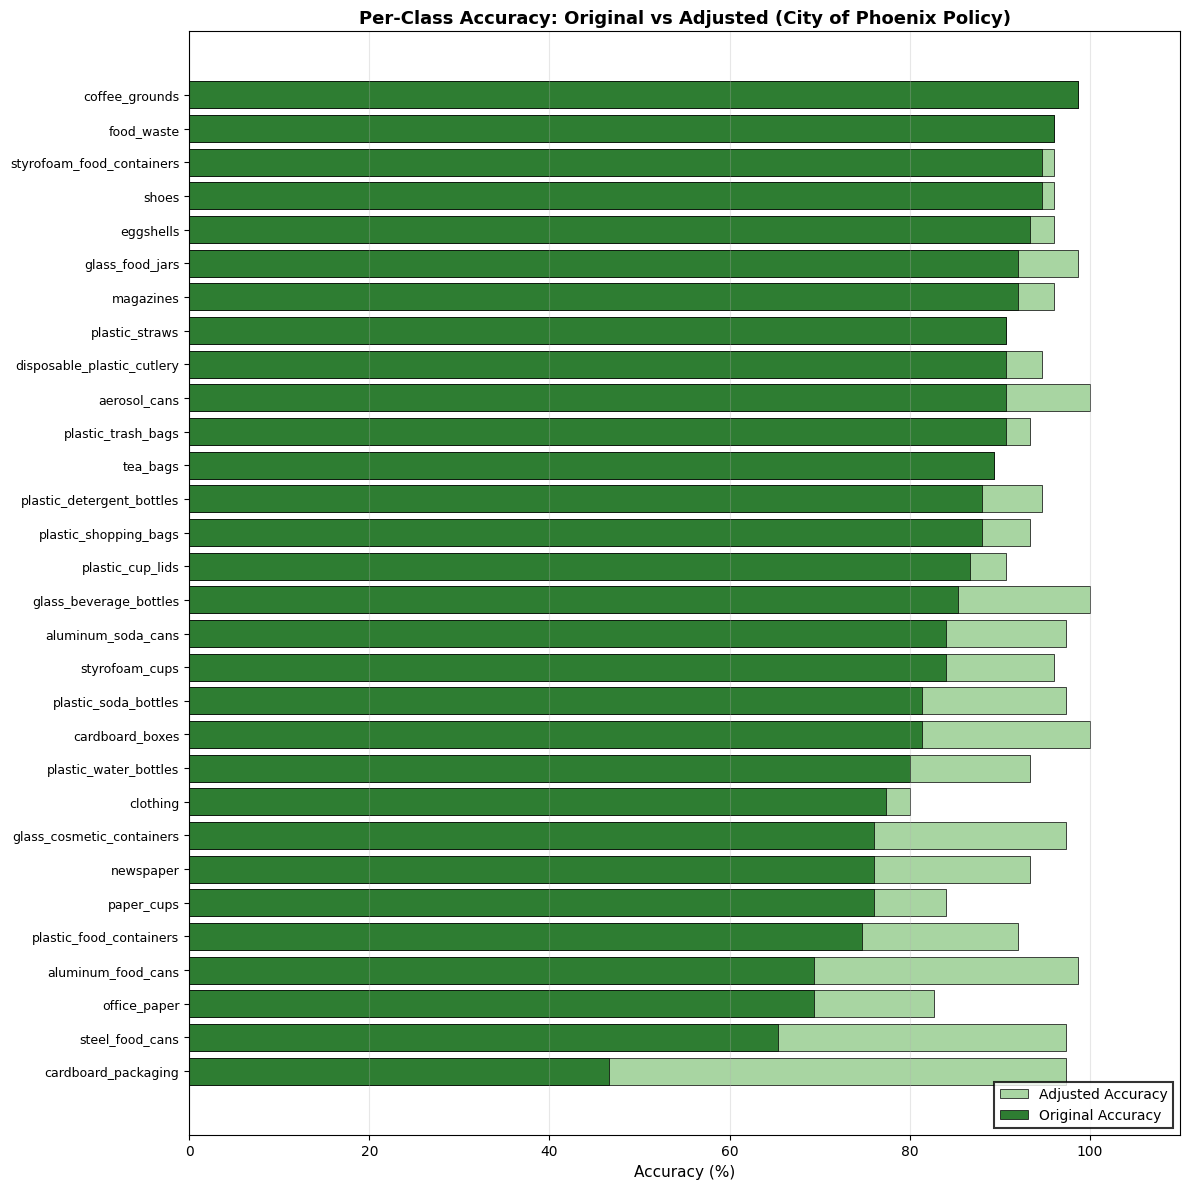

Original Accuracy: 0.8342
Adjusted Accuracy: 0.9436
Pathway Gain:      +0.1093


In [20]:
# Compute adjusted accuracy: correct if predicted class shares a disposal pathway with the true class
adjusted_correct = np.zeros(NUM_CLASSES)
class_counts     = np.zeros(NUM_CLASSES)

for true_idx, pred_idx in zip(all_labels, all_preds):
    true_pathway = DISPOSAL_MAP.get(class_names[true_idx], 'UNMAPPED')
    pred_pathway = DISPOSAL_MAP.get(class_names[pred_idx], 'UNMAPPED')
    class_counts[true_idx] += 1
    if true_pathway == pred_pathway:
        adjusted_correct[true_idx] += 1

adj_acc_per_class = adjusted_correct / class_counts

# Sort by original accuracy ascending so highest is at top of chart
sort_idx     = np.argsort(per_class_accuracy)
sorted_names = [class_names[i] for i in sort_idx]
sorted_orig  = [per_class_accuracy[i] * 100 for i in sort_idx]
sorted_adj   = [adj_acc_per_class[i]  * 100 for i in sort_idx]

y = np.arange(len(sorted_names))

fig, ax = plt.subplots(figsize=(12, 12))

# Draw adjusted accuracy bars first so original bars sit on top
ax.barh(y, sorted_adj,  color='#A8D5A2', label='Adjusted Accuracy', edgecolor='black', linewidth=0.5)
ax.barh(y, sorted_orig, color='#2E7D32', label='Original Accuracy',  edgecolor='black', linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy: Original vs Adjusted (City of Phoenix Policy)', fontweight='bold', fontsize=13)
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

legend = ax.legend(
    loc='lower right',
    frameon=True,
    edgecolor='black',
    fancybox=False,
    fontsize=10
)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()
plt.savefig('/kaggle/working/stage_a_results/stage_a_adjusted_accuracy_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overall accuracy comparison
overall_orig = per_class_accuracy.mean()
overall_adj  = adjusted_correct.sum() / class_counts.sum()
print(f"Original Accuracy: {overall_orig:.4f}")
print(f"Adjusted Accuracy: {overall_adj:.4f}")
print(f"Pathway Gain:      {overall_adj - overall_orig:+.4f}")

The bar chart reveals the adjustment to disposal pathways increase accuracy by over 10%, bringing our new accuracy to **94.36%**.

In [ ]:
# ---------------
# Bar Chart View
# ---------------

per_class_precision_b = precision_score(all_b_labels, all_b_preds, average=None, zero_division=0)
per_class_recall_b    = recall_score(all_b_labels, all_b_preds, average=None, zero_division=0)
per_class_f1_b        = f1_score(all_b_labels, all_b_preds, average=None, zero_division=0)

avg_acc_b  = np.mean(per_class_acc_b)
avg_prec_b = precision_score(all_b_labels, all_b_preds, average='macro', zero_division=0)
avg_rec_b  = recall_score(all_b_labels, all_b_preds, average='macro', zero_division=0)
avg_f1_b   = f1_score(all_b_labels, all_b_preds, average='macro', zero_division=0)

sorted_labels_b    = ['Average'] + [class_names_b[i] for i in sorted_idx_b]
sorted_accuracy_b  = [avg_acc_b]  + [per_class_acc_b[i]       for i in sorted_idx_b]
sorted_precision_b = [avg_prec_b] + [per_class_precision_b[i] for i in sorted_idx_b]
sorted_recall_b    = [avg_rec_b]  + [per_class_recall_b[i]    for i in sorted_idx_b]
sorted_f1_b        = [avg_f1_b]   + [per_class_f1_b[i]        for i in sorted_idx_b]

x_b   = np.arange(len(sorted_labels_b))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x_b - 1.5*width, sorted_accuracy_b,  width, label='Accuracy',  color='steelblue',   edgecolor='black', linewidth=0.8)
ax.bar(x_b - 0.5*width, sorted_precision_b, width, label='Precision', color='tomato',       edgecolor='black', linewidth=0.8)
ax.bar(x_b + 0.5*width, sorted_recall_b,    width, label='Recall',    color='seagreen',     edgecolor='black', linewidth=0.8)
ax.bar(x_b + 1.5*width, sorted_f1_b,        width, label='F1 Score',  color='mediumpurple', edgecolor='black', linewidth=0.8)

ax.set_title('Stage B Contamination Classifier Per-Class Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x_b)
ax.set_xticklabels(sorted_labels_b, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/stage_b_results/stage_b_per_class_metrics_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall Metrics")
print(f"{'='*40}")
print(f"Accuracy:  {avg_acc_b:.4f}")
print(f"Precision: {avg_prec_b:.4f}")
print(f"Recall:    {avg_rec_b:.4f}")
print(f"F1 Score:  {avg_f1_b:.4f}")
print(f"ROC-AUC:   {auc_score:.4f}")

### 3.7 Confusion Matrix

The 2x2 confusion matrix shows the breakdown of true and predicted labels across the clean and contaminated classes. Each row represents the actual class and each column represents the predicted class. The matrix is normalized so each row sums to 1.

In [ ]:
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_b_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names_b,
    yticklabels=class_names_b,
    ax=ax,
    linewidths=1,
    annot_kws={'size': 14},
    vmin=0,
    vmax=1
)

ax.set_title('Stage B Contamination Classifier Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/stage_b_results/stage_b_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.8 Grad-CAM Explainability

Grad-CAM (Gradient-weighted Class Activation Mapping) highlights the regions of the image that most influenced the model's contamination prediction. For a contaminated item the heatmap should concentrate over the contaminated surface area. For a clean item the activation should spread across the whole object with no concentrated hot spot.

The technique works by computing the gradient of the predicted contamination probability with respect to the feature maps of the last convolutional layer (`conv_1`) inside the MobileNetV3Large backbone. Each feature map is weighted by its global average gradient and the weighted sum is ReLU-activated to retain only the regions that pushed the prediction toward contamination. The resulting heatmap is upsampled to 224x224 and overlaid on the original image using the `jet` colormap.

We sample 5 contaminated and 5 clean images from the test set and display each original image alongside its Grad-CAM overlay.

In [ ]:
import matplotlib.cm as cm_plt

def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('MobileNetV3Large')

    # Build a model from the Stage B input to the backbone's last conv output and the final prediction
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[backbone.get_layer('conv_1').output, model.output]
    )

    with tf.GradientTape() as tape:
        inputs_tensor             = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inputs_tensor, training=False)
        loss                      = predictions[:, 0]  # Contamination probability

    # Weight each feature map channel by its average gradient
    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.nn.relu(heatmap)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_rgb, heatmap, alpha=0.45):
    heatmap_up = np.array(
        Image.fromarray((heatmap * 255).astype(np.uint8)).resize(
            (img_rgb.shape[1], img_rgb.shape[0]), Image.BILINEAR
        )
    ).astype(np.float32) / 255.0
    colormap  = cm_plt.get_cmap('jet')
    heatmap_c = colormap(heatmap_up)[:, :, :3]
    overlay   = (img_rgb.astype(np.float32) / 255.0) * (1 - alpha) + heatmap_c * alpha
    return (np.clip(overlay, 0, 1) * 255).astype(np.uint8)

# Collect 5 contaminated and 5 clean images from the test set
gc_images_clean = []
gc_images_cont  = []

for images, labels in test_b_ds.unbatch():
    label = int(labels.numpy())
    img   = images.numpy().astype(np.uint8)
    if label == 0 and len(gc_images_clean) < 5:
        gc_images_clean.append(img)
    elif label == 1 and len(gc_images_cont) < 5:
        gc_images_cont.append(img)
    if len(gc_images_clean) >= 5 and len(gc_images_cont) >= 5:
        break

# Plot 5 contaminated then 5 clean — each row: original | Grad-CAM
all_gc_samples = [(img, 'contaminated') for img in gc_images_cont] + \
                 [(img, 'clean')        for img in gc_images_clean]

fig, axes = plt.subplots(10, 2, figsize=(8, 40))

for row, (img_rgb, true_label) in enumerate(all_gc_samples):
    img_input  = np.expand_dims(img_rgb.astype(np.float32), axis=0)
    prob       = float(best_model_b.predict(img_input, verbose=0)[0, 0])
    pred_label = 'contaminated' if prob >= 0.5 else 'clean'
    correct    = pred_label == true_label

    heatmap     = make_gradcam_heatmap(img_input, best_model_b)
    cam_img     = overlay_gradcam(img_rgb, heatmap)
    title_color = '#2E7D32' if correct else '#B71C1C'
    result_str  = 'Correct' if correct else 'Incorrect'

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"Original  |  True: {true_label}", fontsize=8)

    axes[row, 1].imshow(cam_img)
    axes[row, 1].axis('off')
    axes[row, 1].set_title(
        f"Grad-CAM  |  Pred: {pred_label} ({prob:.2f})  [{result_str}]",
        fontsize=8, color=title_color, fontweight='bold'
    )

plt.suptitle('Stage B Grad-CAM Explainability (Top 5: contaminated, Bottom 5: clean)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/stage_b_results/stage_b_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /kaggle/working/stage_b_results/stage_b_gradcam.png")